# A6: Speech Processing

In this lab, we cover the full speech pipeline across five parts:

1. **Speech Tokenization** — why audio tokenization is fundamentally different from NLP text tokenization
2. **Mel Spectrogram** — the shared bridge representation between raw audio and every model below
3. **CTC** — solving the alignment problem between audio frames and text, implemented from scratch
4. **wav2vec2** — probing a pretrained self-supervised speech encoder (same linear-probe idea as the SSL lab)
5. **Voice Cloning + Expressive TTS** — synthesizing speech in a specific person's voice with a pretrained model (OpenVoice)

---
## The Two Core Tasks

| Task | Direction | Key Challenge |
|---|---|---|
| **ASR** | Audio → Text | Align continuous audio frames to discrete tokens |
| **TTS** | Text → Audio | Map discrete tokens back to a continuous, expressive waveform |

Both tasks go through the same bridge: the **Mel Spectrogram** — a 2D time-frequency representation that compresses raw audio into a form neural networks can process.

**Papers:** [CTC](https://www.cs.toronto.edu/~graves/icml_2006.pdf) · [wav2vec 2.0](https://arxiv.org/abs/2006.11477) · [OpenVoice](https://arxiv.org/abs/2312.01479)

---

In [1]:
!pip install -U torch torchvision torchaudio torchcodec soundfile

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Audio, display
import os, re

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
os.makedirs('data/speech', exist_ok=True)

Using device: cuda


---
# Part 1: Speech Tokenization — Why It's Different from NLP

## 1.1 How NLP Tokenizes Text

In NLP (e.g., BERT, GPT), tokenization is conceptually simple:

```
"Hello world" → ["Hello", "world"] → [7592, 2088]   # word-level
"Hello world" → ["He", "llo", "▁world"] → [1544, 7414, 2088]  # BPE (subword)
```

- **Discrete**: text IS already a sequence of discrete symbols
- **Fixed vocabulary**: 30,000–50,000 tokens, every token is equally "sized"
- **No alignment problem**: token boundaries are explicit (spaces, subword splits)
- **One token = one meaning unit** (roughly)

## 1.2 Why Audio Is Fundamentally Different

Audio is a **continuous** signal sampled at 16,000–44,100 points per second. There are **no natural boundaries** between sounds.

```
"Hello" spoken aloud:
→ 32,000 raw sample values (2 seconds at 16kHz)
→ No spaces, no punctuation, no clear cut points
→ The same word spoken fast vs slow has VERY different lengths
```

**The core problem:** How do you tokenize something continuous?

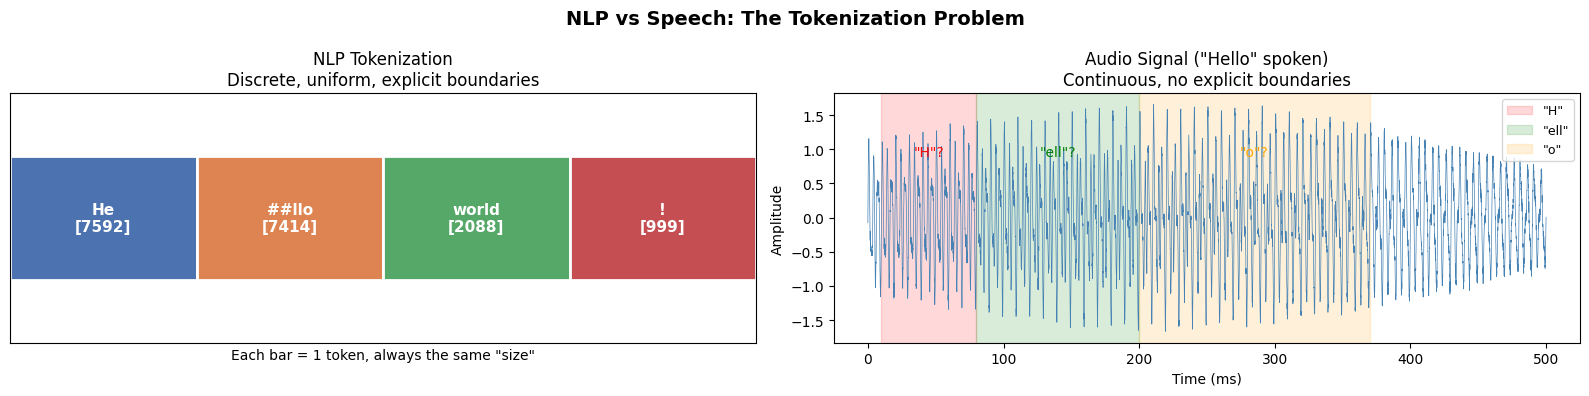

Key difference:
NLP  → text already IS tokens → just look up in vocabulary
Audio → must DECIDE where tokens are → no obvious boundaries


In [3]:
# ── Visualize: NLP token vs Audio signal side by side ──────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left: NLP tokenization — discrete, uniform
ax = axes[0]
tokens = ['He', '##llo', 'world', '!']
token_ids = [7592, 7414, 2088, 999]
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
for i, (tok, tid, col) in enumerate(zip(tokens, token_ids, colors)):
    ax.barh(0, 1, left=i, height=0.5, color=col, edgecolor='white', linewidth=2)
    ax.text(i + 0.5, 0, f'{tok}\n[{tid}]', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
ax.set_xlim(0, 4); ax.set_ylim(-0.5, 0.5)
ax.set_yticks([]); ax.set_xticks([])
ax.set_title('NLP Tokenization\nDiscrete, uniform, explicit boundaries', fontsize=12)
ax.set_xlabel('Each bar = 1 token, always the same "size"')

# Right: audio signal — continuous, no boundaries
ax2 = axes[1]
t = np.linspace(0, 0.5, 8000)
# Simulate a rough "Hello" envelope
signal = (np.sin(2*np.pi*300*t) * np.exp(-10*(t-0.05)**2) * 0.8 +
          np.sin(2*np.pi*500*t) * np.exp(-15*(t-0.2)**2) * 0.6 +
          np.sin(2*np.pi*200*t) * np.exp(-20*(t-0.35)**2) * 0.9)
signal += np.random.randn(len(t)) * 0.05
ax2.plot(t * 1000, signal, color='steelblue', linewidth=0.5)
ax2.axvspan(10, 80,   alpha=0.15, color='red',    label='"H"')
ax2.axvspan(80, 200,  alpha=0.15, color='green',  label='"ell"')
ax2.axvspan(200,370,  alpha=0.15, color='orange', label='"o"')
ax2.set_title('Audio Signal ("Hello" spoken)\nContinuous, no explicit boundaries', fontsize=12)
ax2.set_xlabel('Time (ms)'); ax2.set_ylabel('Amplitude')
ax2.legend(loc='upper right', fontsize=9)
ax2.text(45,  0.9, '"H"?',  ha='center', fontsize=10, color='red')
ax2.text(140, 0.9, '"ell"?', ha='center', fontsize=10, color='green')
ax2.text(285, 0.9, '"o"?',  ha='center', fontsize=10, color='orange')

plt.suptitle('NLP vs Speech: The Tokenization Problem', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('Key difference:')
print('NLP  → text already IS tokens → just look up in vocabulary')
print('Audio → must DECIDE where tokens are → no obvious boundaries')

## 1.3 The Three Approaches to Speech Tokenization

Because audio has no natural token boundaries, researchers invented three different strategies:

### Approach 1: Character/Grapheme Tokens (Tacotron style)
Tokenize the **text input** as characters: `H e l l o → [H][e][l][l][o]`.
The model learns to map each character to a variable-length stretch of audio frames.

**Problem:** Same character sounds different in different words. `c` in `cat` vs `ceiling` — completely different sounds!

### Approach 2: Phoneme Tokens
Convert text to **phonemes** — the minimal units of sound: `Hello → HH EH L OW`.
Each phoneme is a distinct sound unit with a defined pronunciation.

**Advantage:** Pronunciation is explicit. `c` in `cat` → `K`, `c` in `ceiling` → `S`.
**Problem:** Need a g2p (grapheme-to-phoneme) converter. Different for every language.

### Approach 3: Acoustic Tokens (Codec-based, modern)
Compress the **audio itself** into discrete tokens using a neural codec (e.g., EnCodec, SoundStream).
Audio frames → VQ-VAE codebook → discrete token IDs.

**Advantage:** Language models (like GPT) can directly predict audio tokens — no separate vocoder needed.
**Used in:** VALL-E, AudioLM, SoundStorm.

The key insight: in all approaches, there is an **alignment problem** that NLP doesn't have.

In [5]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/todsavadt/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [6]:
# ── Demonstrate the three tokenization approaches ──────────────────────────

text = "Hello world"
print('='*60)
print(f'Input text: "{text}"')
print('='*60)

# --- Approach 1: Character tokens ---
char_vocab = {c: i for i, c in enumerate(sorted(set(" abcdefghijklmnopqrstuvwxyz".upper())))
              }
char_tokens = list(text.upper())
char_ids    = [char_vocab.get(c, -1) for c in char_tokens]
print(f'\n[Approach 1] Character tokens:')
print(f'  Tokens: {char_tokens}')
print(f'  IDs:    {char_ids}')
print(f'  Length: {len(char_tokens)} tokens')
print(f'  Problem: "C" in cat vs ceiling = same token, different sound!')

# --- Approach 2: Phoneme tokens (using g2p_en) ---
# !pip install g2p_en
try:
    from g2p_en import G2p
    g2p = G2p()
    phonemes = g2p(text)
    phonemes = [p for p in phonemes if p != ' ']
    print(f'\n[Approach 2] Phoneme tokens:')
    print(f'  Phonemes: {phonemes}')
    print(f'  Length:   {len(phonemes)} phonemes')
    print(f'  Each symbol = one unique sound (ARPAbet standard)')

    # Compare: cat vs ceiling — same 'c', different phonemes
    print(f'\n  Contrast: "cat"     → {g2p("cat")}')
    print(f'            "ceiling" → {g2p("ceiling")}')
    print(f'  → Same letter C, completely different phonemes!')
except ImportError:
    print(f'\n[Approach 2] Phoneme tokens (install g2p_en to run):')
    print(f'  "Hello world" → [HH EH L OW W ER L D]')
    print(f'  "cat"     → [K AE T]  vs  "ceiling" → [S IY L IH NG]')
    print(f'  → Same letter C, different phonemes!')

# --- Approach 3: Acoustic tokens (conceptual demo) ---
print(f'\n[Approach 3] Acoustic tokens (codec-based):')
print(f'  Audio waveform → EnCodec/SoundStream (VQ-VAE) → discrete codes')
print(f'  e.g., 24kHz audio → 75 tokens/sec (at 320 hop) × 8 codebooks')
print(f'  "Hello world" (1s) → ~75 primary tokens + 75×7 refinement tokens')
print(f'  Can be modeled by a language model (VALL-E, AudioLM)')
print(f'  No pronunciation dictionary needed — works for any language/sound')
print(f'  Tradeoff: very long sequences — 1s audio = 600 tokens total (vs 2 words in NLP)')

Input text: "Hello world"

[Approach 1] Character tokens:
  Tokens: ['H', 'E', 'L', 'L', 'O', ' ', 'W', 'O', 'R', 'L', 'D']
  IDs:    [8, 5, 12, 12, 15, 0, 23, 15, 18, 12, 4]
  Length: 11 tokens
  Problem: "C" in cat vs ceiling = same token, different sound!

[Approach 2] Phoneme tokens:
  Phonemes: ['HH', 'AH0', 'L', 'OW1', 'W', 'ER1', 'L', 'D']
  Length:   8 phonemes
  Each symbol = one unique sound (ARPAbet standard)

  Contrast: "cat"     → ['K', 'AE1', 'T']
            "ceiling" → ['S', 'IY1', 'L', 'IH0', 'NG']
  → Same letter C, completely different phonemes!

[Approach 3] Acoustic tokens (codec-based):
  Audio waveform → EnCodec/SoundStream (VQ-VAE) → discrete codes
  e.g., 24kHz audio → 75 tokens/sec (at 320 hop) × 8 codebooks
  "Hello world" (1s) → ~75 primary tokens + 75×7 refinement tokens
  Can be modeled by a language model (VALL-E, AudioLM)
  No pronunciation dictionary needed — works for any language/sound
  Tradeoff: very long sequences — 1s audio = 600 tokens total (vs

## 1.4 The Alignment Problem — Why Speech Has CTC and NLP Doesn't

Even after choosing a tokenization approach, there's still the **alignment problem**:

```
Text:  H  E  L  L  O        ← 5 tokens
Audio: ████████████████████  ← 200 frames

Which frames correspond to which token?
```

In NLP, the input and output are both token sequences of similar length — no alignment needed. In speech, the input (audio frames) and output (text tokens) have very different lengths.

**CTC (Connectionist Temporal Classification)** solves this by:
- Allowing the model to output a special `<blank>` token for "nothing here yet"
- Summing over all valid alignments that collapse to the correct text
- Example: `_H_EE_LL_O_` and `HH_E_L_LO` both collapse to `HELLO`

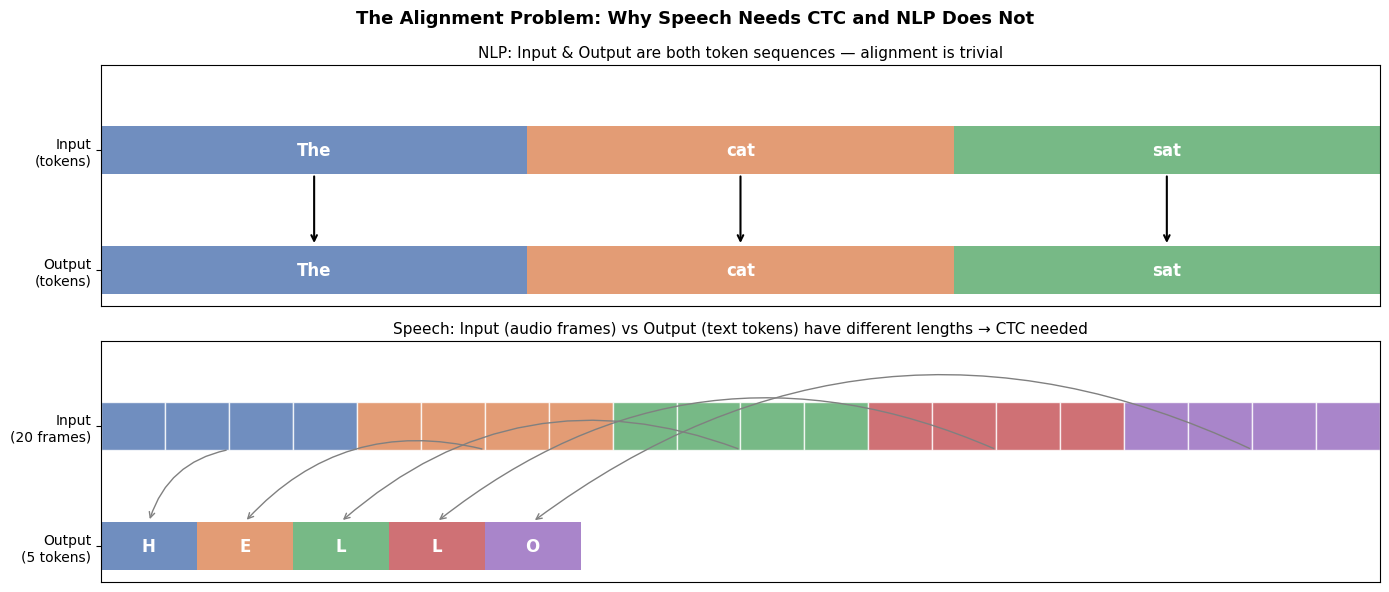

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

ax = axes[0]
nlp_tokens = ['The', 'cat', 'sat']
colors_nlp = ['#4C72B0', '#DD8452', '#55A868']

for i, (tok, col) in enumerate(zip(nlp_tokens, colors_nlp)):
    ax.barh(1, 3, left=i*3, height=0.4, color=col, alpha=0.8)
    ax.text(i*3+1.5, 1, tok, ha='center', va='center',
            fontsize=12, color='white', fontweight='bold')
    ax.barh(0, 3, left=i*3, height=0.4, color=col, alpha=0.8)
    ax.text(i*3+1.5, 0, tok, ha='center', va='center',
            fontsize=12, color='white', fontweight='bold')
    ax.annotate('',
                xy=(i*3+1.5, 0.2),
                xytext=(i*3+1.5, 0.8),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.set_xlim(0, 9)
ax.set_ylim(-0.3, 1.7)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Output\n(tokens)', 'Input\n(tokens)'])
ax.set_xticks([])
ax.set_title('NLP: Input & Output are both token sequences — alignment is trivial',
             fontsize=11)

ax2 = axes[1]
n_audio_frames = 20
text_tokens = ['H', 'E', 'L', 'L', 'O']

frame_colors = (['#4C72B0']*4 + ['#DD8452']*4 + ['#55A868']*4 +
                ['#C44E52']*4 + ['#9467BD']*4)
token_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#9467BD']

for i in range(n_audio_frames):
    ax2.barh(1, 1, left=i, height=0.4,
             color=frame_colors[i], alpha=0.8, edgecolor='white')

for i, (tok, col) in enumerate(zip(text_tokens, token_colors)):
    ax2.barh(0, 1.5, left=i*1.5, height=0.4, color=col, alpha=0.8)
    ax2.text(i*1.5+0.75, 0, tok, ha='center', va='center',
             fontsize=12, color='white', fontweight='bold')

    mid_frame = i*4 + 2

    ax2.annotate('',
                 xy=(i*1.5+0.75, 0.2),
                 xytext=(mid_frame, 0.8),
                 arrowprops=dict(
                     arrowstyle='->',
                     color='gray',
                     lw=1,
                     connectionstyle='arc3,rad=0.3'
                 ))

ax2.set_xlim(0, 20)
ax2.set_ylim(-0.3, 1.7)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Output\n(5 tokens)', 'Input\n(20 frames)'])
ax2.set_xticks([])
ax2.set_title(
    'Speech: Input (audio frames) vs Output (text tokens) have different lengths → CTC needed',
    fontsize=11)

plt.suptitle('The Alignment Problem: Why Speech Needs CTC and NLP Does Not',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.5 How TTS Tokenizes: The Full Pipeline

For TTS (Text-to-Speech), the tokenization flows in the opposite direction:

```
"Hello world"
      ↓  [Text Normalization]
"hello world"  (expand numbers, abbreviations: "Dr." → "Doctor", "5" → "five")
      ↓  [G2P / Character Encoding]
[HH, EH, L, OW, W, ER, L, D]  (phonemes OR characters)
      ↓  [Token Embedding]
Sequence of 512-dim vectors
      ↓  [Tacotron / FastSpeech encoder-decoder]
Mel Spectrogram  (80 bins × T frames)   ← the "image" of speech
      ↓  [Vocoder: WaveNet / HiFi-GAN]
Audio waveform  (16,000 samples/sec)
```

The **duration problem**: each input token must be stretched to cover a variable number of output frames. "Hello" takes ~200ms but "Supercalifragilistic" takes ~800ms.

- **Tacotron**: learns duration implicitly via attention (soft, flexible, but sometimes skips tokens)
- **FastSpeech**: learns duration explicitly via a duration predictor (more stable, fully parallel)

In [8]:
# ── Build a character-level tokenizer from scratch ──────────────────────────

class SpeechTokenizer:
    """
    Character-level tokenizer for TTS.
    Handles: text normalization, special tokens, accent tags.
    """
    ACCENTS = ['[EN-US]', '[EN-BR]', '[EN-INDIA]', '[EN-AU]', '[EN-DEFAULT]']

    def __init__(self):
        # Base vocabulary: printable ASCII
        chars = " !',-.?abcdefghijklmnopqrstuvwxyz"
        self.vocab = {c: i+3 for i, c in enumerate(chars)}
        self.vocab['<PAD>'] = 0
        self.vocab['<BOS>'] = 1
        self.vocab['<EOS>'] = 2
        # Add accent tag tokens
        for i, a in enumerate(self.ACCENTS):
            self.vocab[a] = len(self.vocab)
        self.inv_vocab = {v: k for k, v in self.vocab.items()}

    def normalize(self, text):
        """Basic text normalization: lowercase, expand common abbreviations."""
        text = text.lower()
        text = re.sub(r'dr\.', 'doctor', text)
        text = re.sub(r'mr\.', 'mister', text)
        text = re.sub(r'(\d+)', lambda m: self._num_to_words(int(m.group())), text)
        text = re.sub(r'[^a-z !\',\-.?\[\]]', '', text)
        return text.strip()

    def _num_to_words(self, n):
        words = {0:'zero',1:'one',2:'two',3:'three',4:'four',5:'five',
                 6:'six',7:'seven',8:'eight',9:'nine',10:'ten'}
        return words.get(n, str(n))

    def encode(self, text, add_special=True):
        """
        Tokenize text (with optional accent tags).
        Accent tags like [EN-US] are treated as single tokens, not character-by-character.
        """
        tag_pattern = '|'.join(re.escape(a) for a in self.ACCENTS)
        parts = re.split(f'({tag_pattern})', text)
        tokens = []
        if add_special: tokens.append(self.vocab['<BOS>'])
        for part in parts:
            if part in self.ACCENTS:
                tokens.append(self.vocab[part])  # accent tag = single token
            else:
                normalized = self.normalize(part)
                for ch in normalized:
                    if ch in self.vocab:
                        tokens.append(self.vocab[ch])
        if add_special: tokens.append(self.vocab['<EOS>'])
        return tokens

    def decode(self, ids):
        return ''.join(self.inv_vocab.get(i, '?') for i in ids
                       if i not in (self.vocab['<PAD>'], self.vocab['<BOS>'], self.vocab['<EOS>']))

    def __len__(self): return len(self.vocab)


tokenizer = SpeechTokenizer()
print(f'Vocabulary size: {len(tokenizer)}')
print(f'Special tokens: PAD={tokenizer.vocab["<PAD>"]}, BOS={tokenizer.vocab["<BOS>"]}, EOS={tokenizer.vocab["<EOS>"]}')
print(f'Accent tokens: {[(a, tokenizer.vocab[a]) for a in SpeechTokenizer.ACCENTS]}')


Vocabulary size: 42
Special tokens: PAD=0, BOS=1, EOS=2
Emotion tokens: [('[NEUTRAL]', 36), ('[HAPPY]', 37), ('[SAD]', 38), ('[ANGRY]', 39), ('[SURPRISED]', 40), ('[FEARFUL]', 41)]


In [9]:
# ── Demonstrate tokenization: NLP vs Speech ─────────────────────────────────

test_sentences = [
    "Hello world",
    "Dr. Smith saw 5 patients.",
    "[EN-US] This is American English.",
    "[EN-BR] This is British English.",
    "[EN-INDIA] This is Indian English.",
]

print('=' * 65)
print(f'{"Input":35} {"Tokens":6} {"Accent Tag"}')
print('=' * 65)
for sent in test_sentences:
    ids   = tokenizer.encode(sent)
    back  = tokenizer.decode(ids)
    tag   = [a for a in SpeechTokenizer.ACCENTS if a in sent]
    print(f'{sent[:33]:35} {len(ids):6}  {tag[0] if tag else "—"}')

print('\n--- Detail: "[EN-US] Hello world" ---')
sent = "[EN-US] Hello world"
ids = tokenizer.encode(sent)
print(f'Input:   {sent}')
print(f'IDs:     {ids}')
print(f'Decoded: {tokenizer.decode(ids)}')
print(f'\nKey: [EN-US] = single token ID {tokenizer.vocab["[EN-US]"]} (not [, E, N, -, U, S, ])')
print(f'     Just like [CLS] in BERT — one special token = one embedding')


Input                               Tokens Emotion Tag
Hello world                             13  —
Dr. Smith saw 5 patients.               33  —
[HAPPY] I got the job!                  17  [HAPPY]
[SAD] I missed the train.               22  [SAD]
[ANGRY] This is unacceptable!           24  [ANGRY]

--- Detail: "[HAPPY] I got the job!" ---
Input:   [HAPPY] I got the job!
IDs:     [1, 37, 18, 3, 16, 24, 29, 3, 29, 17, 14, 3, 19, 24, 11, 4, 2]
Decoded: [HAPPY]i got the job!

Key: [HAPPY] = single token ID 37 (not [, H, A, P, P, Y, ])
     Just like [CLS] in BERT — one special token = one embedding


## 1.6 NLP Tokenizer vs Speech Tokenizer — Side-by-Side Comparison

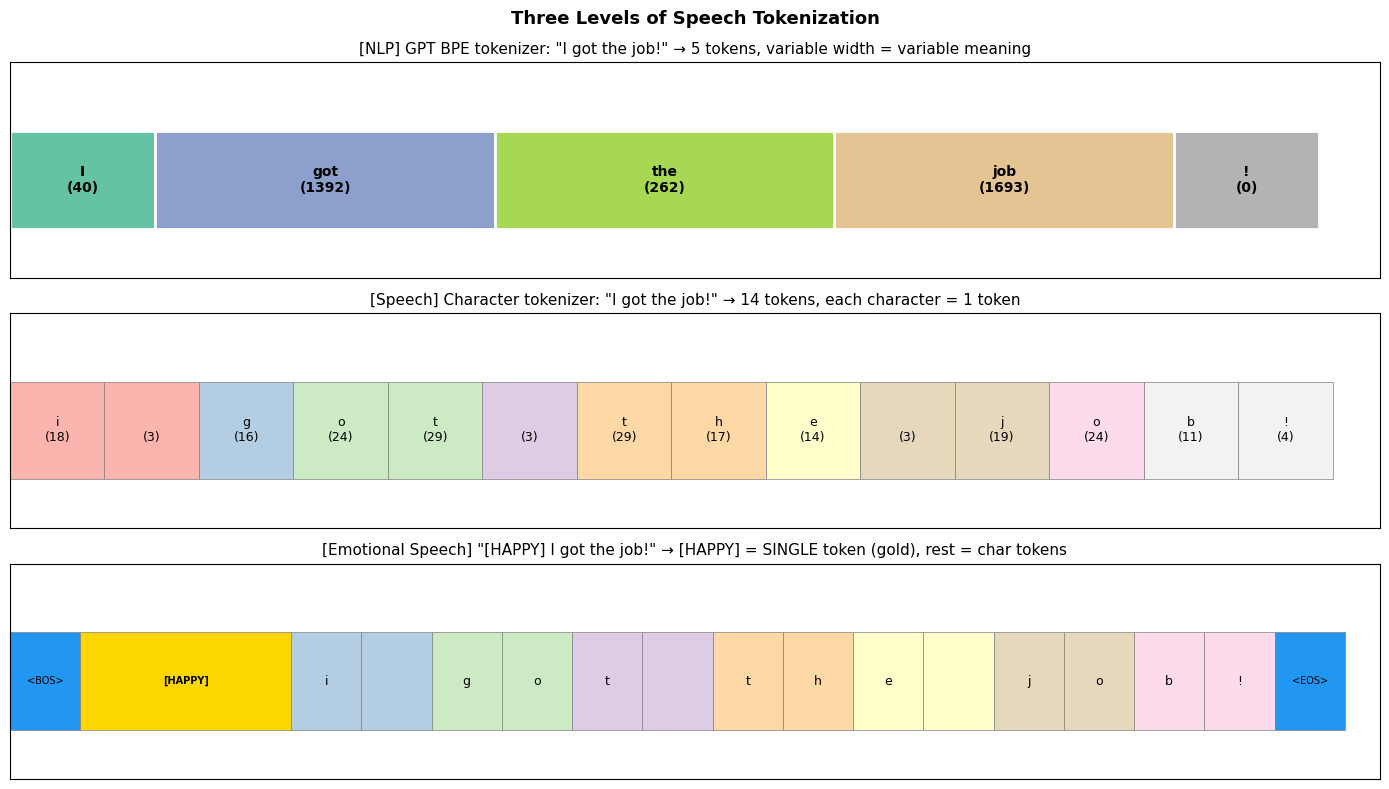

In [10]:
# ── Visualization: tokenization comparison ──────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 8))
sentence = "I got the job!"

# --- NLP BPE tokenization ---
nlp_tokens = ['I', 'got', 'the', 'job', '!']
nlp_ids    = [40, 1392, 262, 1693, 0]
ax = axes[0]
colors = plt.cm.Set2(np.linspace(0, 1, len(nlp_tokens)))
x = 0
for tok, tid, col in zip(nlp_tokens, nlp_ids, colors):
    w = len(tok) * 0.8 + 0.4
    ax.barh(0, w, left=x, height=0.5, color=col, edgecolor='white', lw=2)
    ax.text(x+w/2, 0, f'{tok}\n({tid})', ha='center', va='center', fontsize=10, fontweight='bold')
    x += w
ax.set_xlim(0, x+0.5); ax.set_ylim(-0.5, 0.6)
ax.set_yticks([]); ax.set_xticks([])
ax.set_title(f'[NLP] GPT BPE tokenizer: "{sentence}" → 5 tokens, variable width = variable meaning', fontsize=11)

# --- Speech character tokenization ---
chars = list(sentence.lower())
char_ids = [tokenizer.vocab.get(c, -1) for c in chars]
ax2 = axes[1]
colors2 = plt.cm.Pastel1(np.linspace(0, 1, len(chars)))
for i, (ch, cid, col) in enumerate(zip(chars, char_ids, colors2)):
    ax2.barh(0, 1, left=i, height=0.5, color=col, edgecolor='gray', lw=0.5)
    ax2.text(i+0.5, 0, f'{ch}\n({cid})', ha='center', va='center', fontsize=9)
ax2.set_xlim(0, len(chars)+0.5); ax2.set_ylim(-0.5, 0.6)
ax2.set_yticks([]); ax2.set_xticks([])
ax2.set_title(f'[Speech] Character tokenizer: "{sentence}" → {len(chars)} tokens, each character = 1 token', fontsize=11)

# --- Accent-tagged version ---
sent_acc = f'[EN-US] {sentence}'
acc_ids  = tokenizer.encode(sent_acc)
acc_disp = [tokenizer.inv_vocab[i] for i in acc_ids]
ax3 = axes[2]
widths = [3.5 if t.startswith('[EN') else 1.0 for t in acc_disp]
acc_colors_list = ['steelblue' if t.startswith('[EN') else
                   ('#2196F3' if t in ('<BOS>','<EOS>') else
                    plt.cm.Pastel1(i/len(acc_disp)))
                   for i, t in enumerate(acc_disp)]
x = 0
for tok, w, col in zip(acc_disp, widths, acc_colors_list):
    ax3.barh(0, w, left=x, height=0.5, color=col, edgecolor='gray', lw=0.5)
    fontsize = 8 if len(tok) <= 5 else 7
    ax3.text(x+w/2, 0, tok, ha='center', va='center', fontsize=fontsize,
             fontweight='bold' if w > 1 else 'normal')
    x += w
ax3.set_xlim(0, x+0.5); ax3.set_ylim(-0.5, 0.6)
ax3.set_yticks([]); ax3.set_xticks([])
ax3.set_title(f'[Accent-Tagged Speech] "{sent_acc}" → [EN-US] = SINGLE token (blue), rest = char tokens', fontsize=11)

plt.suptitle('Three Levels of Speech Tokenization', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
# Part 2: Mel Spectrogram — The Bridge Between Tokens and Audio

After tokenization, TTS must produce a Mel Spectrogram. Let's first understand what a spectrogram looks like, then see how a real trained model (Tacotron 2) connects text tokens to mel frames through an alignment matrix.

<img src="figures/tacotron2_alignment_and_mel.png" title="Tacotron 2: decoder alignment matrix (left) and predicted vs ground-truth mel spectrogram (middle/right)" style="width: 900px;" />

The leftmost panel is the attention alignment matrix from a trained Tacotron 2 model — decoder timestep on the x-axis, input (text) position on the y-axis. The near-diagonal line is exactly the "which frames correspond to which token" alignment problem from Part 1, learned automatically by attention instead of hand-specified. The middle and right panels are the predicted mel spectrogram and the ground-truth mel spectrogram for the same utterance — visually almost identical, which is what the model is trained to achieve.

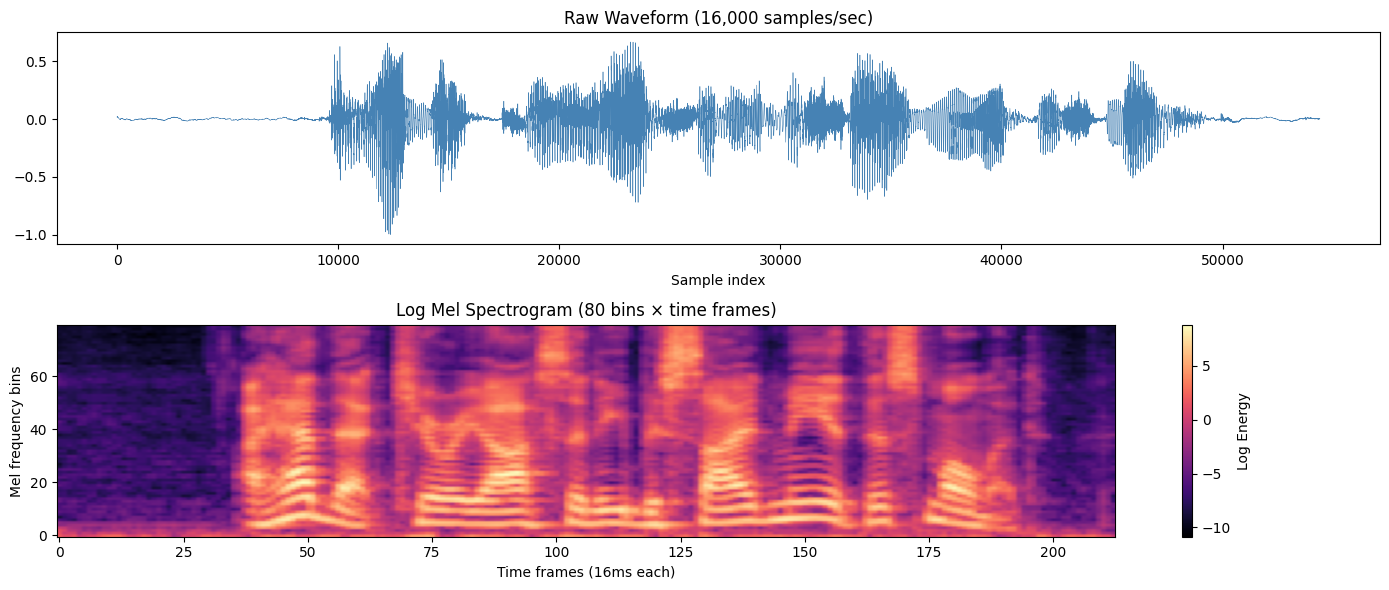

In [11]:
import urllib.request, os

# Download the sample WAV directly
url = "https://download.pytorch.org/torchaudio/tutorial-assets/Lab41-SRI-VOiCES-src-sp0307-ch127535-sg0042.wav"
wav_path = "sample_speech.wav"

if not os.path.exists(wav_path):
    urllib.request.urlretrieve(url, wav_path)

waveform, sample_rate = torchaudio.load(wav_path)
if sample_rate != 16000:
    waveform = T.Resample(sample_rate, 16000)(waveform)
    sample_rate = 16000

mel_tf  = T.MelSpectrogram(sample_rate=16000, n_fft=1024, hop_length=256, n_mels=80)
mel_spec = mel_tf(waveform[0].unsqueeze(0)).squeeze()
log_mel  = torch.log(mel_spec + 1e-9)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(waveform[0].numpy(), linewidth=0.4, color='steelblue')
axes[0].set_title('Raw Waveform (16,000 samples/sec)'); axes[0].set_xlabel('Sample index')

im = axes[1].imshow(log_mel.numpy(), aspect='auto', origin='lower', cmap='magma')
axes[1].set_title('Log Mel Spectrogram (80 bins × time frames)')
axes[1].set_xlabel('Time frames (16ms each)'); axes[1].set_ylabel('Mel frequency bins')
plt.colorbar(im, ax=axes[1], label='Log Energy')
plt.tight_layout(); plt.show()

---
# Part 3: CTC — Solving the Alignment Problem

## 3.1 Recap: Why Speech Needs This and NLP Doesn't

Part 1 already showed the core issue: a 5-character word might span 200 audio frames, and we don't know in advance which frames belong to which character. An ASR model still has to output *something* at every single frame (e.g. one prediction every 10-20ms) — so somehow a 200-length frame sequence has to turn into a 5-character string.

**Connectionist Temporal Classification** (Graves et al., ICML 2006) solves this with two ideas:

1. **Repeat each character across multiple consecutive frames** — `HHHEEELLLLOOO` is an acceptable way to "spell" `HELLO` across 13 frames.
2. **Introduce a blank token `ε`** for frames where nothing new is being said yet, or to separate two instances of the same repeated letter (e.g. the double `L` in `HELLO`) so they don't accidentally get merged into one.

## 3.2 The Collapsing Function

Given any raw frame-level output (an "alignment"), CTC defines a deterministic rule to collapse it down to the final text: merge consecutive duplicate characters, then strip out all blanks.

<img src="figures/ctc_collapsing.png" title="CTC collapsing function: merge repeated characters, then remove blank tokens" style="width: 700px;" />

This is exactly why CTC needs blanks at all: without them, the genuinely-doubled `L` in `HELLO` would incorrectly collapse to a single `L` — the same way a single repeated character would. The blank in between (`...L ε L...`) tells the collapsing function "these are two separate occurrences," not one continuation.

## 3.3 Many Alignments, One Answer

The model never commits to a single frame-level alignment during training — there are many different raw outputs that all collapse to the same correct word. CTC's training objective sums the probability over **every** alignment that collapses correctly, not just the most likely one:

$$P_{CTC}(Y \mid X) = \sum_{A \in \mathcal{B}^{-1}(Y)} \prod_{t} p(a_t \mid X)$$

Naively this sum has exponentially many terms — infeasible to enumerate directly. The trick is the same dynamic-programming idea used in HMMs: a forward-backward recursion that computes the sum in $O(T \cdot |Y|)$ time instead.

<img src="figures/ctc_forward_graph.png" title="CTC forward algorithm: dynamic programming graph over (blank, label) states across timesteps, with two valid final nodes" style="width: 700px;" />

Each row alternates between a blank state and a label state; each column is a timestep. A path through this graph from top-left to one of the two bottom-right "final nodes" is one valid alignment. The forward algorithm sums the probability mass over *all* such paths without ever enumerating them individually — this sum, in log space, is exactly the training loss: $\mathcal{L}_{CTC} = -\log P_{CTC}(Y \mid X)$.

We'll now implement the collapsing function and the forward algorithm from scratch, and train a tiny CTC model on a synthetic frame-to-character task so the alignment is something we can inspect directly.

In [12]:
# ── CTC collapsing function, implemented from scratch ──────────────────────

BLANK = '_'  # ε

def ctc_collapse(alignment):
    """Merge consecutive duplicates, then remove blanks. alignment: list of chars."""
    merged = []
    for ch in alignment:
        if not merged or ch != merged[-1]:
            merged.append(ch)
    return ''.join(ch for ch in merged if ch != BLANK)


examples = [
    list('HHEELLLLOO'),
    list('H_EE_LL_LO'),     # blank separates the two L's correctly
    list('H_E_L_L_O'),
    list('HHHHEEEELLLLLLOOOO'),
]

print('Collapsing function: merge repeats, then strip blanks\n')
for align in examples:
    print(f'  {"".join(align):20} -> {ctc_collapse(align)}')

# Show why the blank matters: without separating ε, two L's wrongly become one
bad_no_blank  = list('HELLLO')     # no blank, can't tell "real double L" from "repeated frame of one L"
print(f'\n  Ambiguous case: "{"".join(bad_no_blank)}" collapses to "{ctc_collapse(bad_no_blank)}"')
print('  (3 consecutive L frames could mean one L stretched out, OR two L'+chr(39)+'s back-to-back —')
print('   the model needs a blank between them whenever the L'+chr(39)+'s are truly separate letters)')

Collapsing function: merge repeats, then strip blanks

  HHEELLLLOO           -> HELO
  H_EE_LL_LO           -> HELLO
  H_E_L_L_O            -> HELLO
  HHHHEEEELLLLLLOOOO   -> HELO

  Ambiguous case: "HELLLO" collapses to "HELO"
  (3 consecutive L frames could mean one L stretched out, OR two L's back-to-back —
   the model needs a blank between them whenever the L's are truly separate letters)


## 3.4 The Forward Algorithm — Computing $P_{CTC}(Y \mid X)$ Without Enumerating Every Alignment

We build the "extended" label sequence by interleaving blanks: `HELLO` → `ε H ε E ε L ε L ε O ε`. The forward variable $\alpha(t, s)$ is the total probability of all valid partial alignments that reach extended-label position $s$ by frame $t$. Two simple recursions cover every case (whether the current label repeats the previous one or not), and the final answer is just $\alpha(T, S) + \alpha(T, S-1)$ — the two valid final nodes shown in the diagram above.

In [13]:
# ── CTC forward algorithm, implemented from scratch (log-space) ────────────
import torch
import numpy as np

NEG_INF = -1e9

def log_add(a, b):
    """log(exp(a) + exp(b)), numerically stable."""
    if a == NEG_INF: return b
    if b == NEG_INF: return a
    m = max(a, b)
    return m + np.log(np.exp(a - m) + np.exp(b - m))


def ctc_forward_log_prob(log_probs, labels, blank=0):
    """
    log_probs: (T, V) log-softmax output per frame, V = vocab size (incl. blank)
    labels:    list of label indices (no blanks), length L
    Returns:   log P_CTC(labels | log_probs)
    """
    T, V = log_probs.shape
    L = len(labels)
    ext = [blank]
    for lab in labels:
        ext += [lab, blank]
    S = len(ext)  # extended length = 2L + 1

    alpha = np.full((T, S), NEG_INF)
    alpha[0, 0] = log_probs[0, ext[0]]
    if S > 1:
        alpha[0, 1] = log_probs[0, ext[1]]

    for t in range(1, T):
        for s in range(S):
            stay = alpha[t-1, s]
            prev = alpha[t-1, s-1] if s - 1 >= 0 else NEG_INF
            skip = NEG_INF
            # can skip over a blank only if current label != label two steps back
            if s - 2 >= 0 and ext[s] != blank and ext[s] != ext[s-2]:
                skip = alpha[t-1, s-2]
            best_prev = log_add(log_add(stay, prev), skip)
            alpha[t, s] = best_prev + log_probs[t, ext[s]]

    if S == 1:
        return alpha[T-1, S-1]
    return log_add(alpha[T-1, S-1], alpha[T-1, S-2])


# ── Sanity check on a tiny hand-built example ───────────────────────────────
# vocab: 0=blank, 1=H, 2=E, 3=L, 4=O
vocab = {0: BLANK, 1: 'H', 2: 'E', 3: 'L', 4: 'O'}
T, V = 6, 5
np.random.seed(0)
logits = np.random.randn(T, V)
log_probs = logits - np.log(np.exp(logits).sum(axis=1, keepdims=True))  # log-softmax

labels_hel = [1, 2, 3]  # "HEL"
logp = ctc_forward_log_prob(log_probs, labels_hel)
print(f'log P_CTC("HEL" | random 6-frame logits) = {logp:.4f}')
print(f'P_CTC("HEL" | ...) = {np.exp(logp):.6f}')
print()
print('This sums the probability over every alignment of length 6 that collapses to "HEL"')
print('(e.g. H_EL__, HH_ELL, _HEELL, ...) — without enumerating them one by one.')

log P_CTC("HEL" | random 6-frame logits) = -5.5957
P_CTC("HEL" | ...) = 0.003714

This sums the probability over every alignment of length 6 that collapses to "HEL"
(e.g. H_EL__, HH_ELL, _HEELL, ...) — without enumerating them one by one.


## 3.5 Training a Tiny CTC Model on a Synthetic Task

Real ASR training data requires downloading and aligning audio corpora, which is heavy for a single lab cell. Instead we synthesize a toy "frame sequence → word" task that has the *exact same structure* as real ASR: a long, noisy frame sequence where each character is smeared across several consecutive frames at an unknown, variable rate — and a CTC-trained model must learn to read it off correctly. We use PyTorch's built-in `nn.CTCLoss` here (a fast, tested implementation of the same forward algorithm we just built by hand) so training is quick; Exercise 1 below asks you to swap in your own loss and confirm the results match.

Step  50 | CTC loss: 2.0042
Step 100 | CTC loss: 0.3693
Step 150 | CTC loss: 0.0585
Step 200 | CTC loss: 0.0299
Step 250 | CTC loss: 0.0386
Step 300 | CTC loss: 0.0175


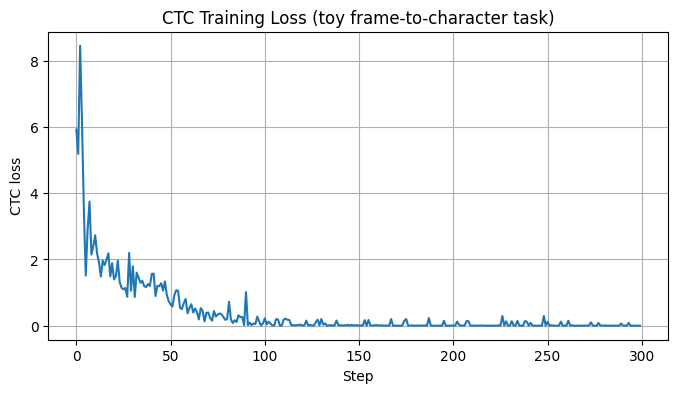

In [14]:
# ── Synthetic frame-to-character ASR task + tiny CTC model ─────────────────
import torch.nn as nn
import torch.nn.functional as F
import random

ALPHABET = list('helo wrd')           # small vocab for our toy words
CHAR2IDX = {c: i+1 for i, c in enumerate(ALPHABET)}   # 0 reserved for blank
IDX2CHAR = {i+1: c for i, c in enumerate(ALPHABET)}
VOCAB_SIZE = len(ALPHABET) + 1        # +1 for blank
N_MELS = 20                           # toy "feature dim" per frame

WORDS = ['hello', 'world', 'hero', 'red', 'led', 'doer']

def synthesize_frames(word, frames_per_char=(3, 8)):
    """Each character is stretched across a random number of frames + noise."""
    frames, char_at_frame = [], []
    for ch in word:
        n = random.randint(*frames_per_char)
        base = np.zeros(N_MELS)
        base[CHAR2IDX[ch] % N_MELS] = 3.0          # a "signature" peak per character
        for _ in range(n):
            frames.append(base + np.random.randn(N_MELS) * 0.5)
            char_at_frame.append(ch)
    return np.stack(frames), char_at_frame


class TinyCTCModel(nn.Module):
    """BiLSTM encoder -> linear -> log-softmax over (blank + alphabet)."""
    def __init__(self, in_dim=N_MELS, hidden=64, vocab=VOCAB_SIZE):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, batch_first=True, bidirectional=True)
        self.fc   = nn.Linear(hidden * 2, vocab)

    def forward(self, x):
        h, _ = self.lstm(x)
        return F.log_softmax(self.fc(h), dim=-1)   # (B, T, V)


model = TinyCTCModel()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
ctc_loss_fn = nn.CTCLoss(blank=0, zero_infinity=True)

losses = []
for step in range(300):
    word = random.choice(WORDS)
    frames, _ = synthesize_frames(word)
    x = torch.tensor(frames, dtype=torch.float32).unsqueeze(0)     # (1, T, N_MELS)
    targets = torch.tensor([CHAR2IDX[c] for c in word], dtype=torch.long)

    log_probs = model(x).transpose(0, 1)   # CTCLoss wants (T, B, V)
    input_lengths  = torch.tensor([log_probs.size(0)])
    target_lengths = torch.tensor([len(targets)])

    loss = ctc_loss_fn(log_probs, targets, input_lengths, target_lengths)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())

    if (step + 1) % 50 == 0:
        print(f'Step {step+1:3d} | CTC loss: {np.mean(losses[-50:]):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title('CTC Training Loss (toy frame-to-character task)')
plt.xlabel('Step'); plt.ylabel('CTC loss'); plt.grid(True)
plt.show()

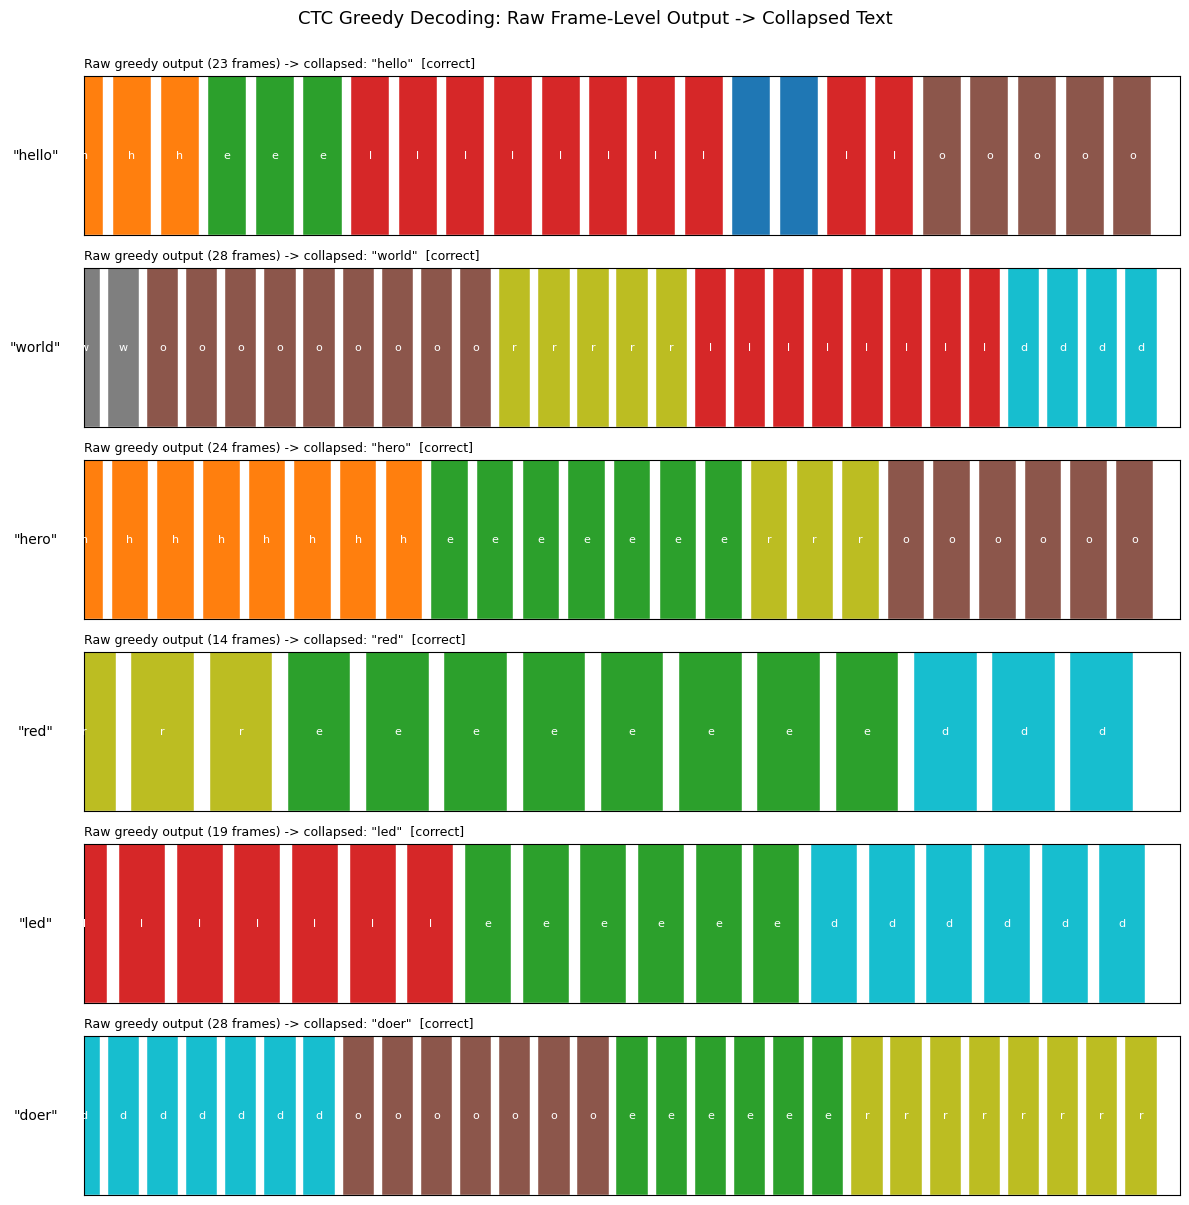

TinyCTCModel(
  (lstm): LSTM(20, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=9, bias=True)
)

In [15]:
# ── Greedy decode: see the model's raw alignment + our collapsing function ──
model.eval()
fig, axes = plt.subplots(len(WORDS), 1, figsize=(12, 2 * len(WORDS)))

for ax, word in zip(axes, WORDS):
    frames, true_chars = synthesize_frames(word)
    x = torch.tensor(frames, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        log_probs = model(x).squeeze(0)            # (T, V)
    pred_ids = log_probs.argmax(dim=-1).tolist()
    pred_chars_raw = [IDX2CHAR.get(i, BLANK) if i != 0 else BLANK for i in pred_ids]
    decoded = ctc_collapse(pred_chars_raw)          # reuse our from-scratch function!

    T = len(pred_chars_raw)
    colors = plt.cm.tab10(np.linspace(0, 1, len(ALPHABET) + 1))
    for t, ch in enumerate(pred_chars_raw):
        idx = 0 if ch == BLANK else ALPHABET.index(ch) + 1
        ax.bar(t, 1, color=colors[idx], edgecolor='white', linewidth=0.3)
        if ch != BLANK:
            ax.text(t, 0.5, ch, ha='center', va='center', fontsize=8, color='white')
    ax.set_xlim(0, T); ax.set_ylim(0, 1)
    ax.set_yticks([]); ax.set_xticks([])
    correct = 'correct' if decoded == word else 'wrong'
    ax.set_ylabel(f'"{word}"', rotation=0, labelpad=35, fontsize=10, va='center')
    ax.set_title(f'Raw greedy output ({T} frames) -> collapsed: "{decoded}"  [{correct}]',
                 fontsize=9, loc='left')

plt.suptitle('CTC Greedy Decoding: Raw Frame-Level Output -> Collapsed Text', fontsize=13, y=1.0)
plt.tight_layout()
plt.show()
model.train()

---
# Part 4: wav2vec 2.0 — Probing a Self-Supervised Speech Encoder

## 4.1 Where This Fits

CTC (Part 3) needs labeled (audio, transcript) pairs to train. Those are expensive — transcribing one hour of audio can take roughly ten hours of human effort. **wav2vec 2.0** (Baevski et al., Meta AI 2020) asks: can a model learn useful speech representations from raw audio *without any transcripts at all*, the same way SSL methods like SimCLR or DINO learn image representations without labels?

<img src="figures/wav2vec2_arch.png" title="wav2vec 2.0: CNN feature extractor -> quantization (Q) for contrastive targets, masked Transformer encoder produces context representations (C)" style="width: 750px;" />

The recipe has three pieces:
1. **CNN feature extractor**: raw waveform → latent speech representations $\mathcal{Z}$ (one vector per ~20ms).
2. **Quantization module**: each latent vector is also mapped to a discrete codebook entry $\mathcal{Q}$ — this becomes the *target* for self-supervision, never seen by the encoder directly.
3. **Masked Transformer**: random spans of $\mathcal{Z}$ are masked before the Transformer; it must predict the *quantized* version of the masked spots, using a **contrastive loss** against a handful of distractor codes.

No transcripts anywhere in this loop. The supervision signal is purely "predict the masked part of your own input" — exactly the same self-supervised philosophy as MAE's masked-patch reconstruction in the SSL lab, just applied to audio frames instead of image patches.

## 4.2 Why We Probe Instead of Pretrain

Pretraining wav2vec 2.0 from scratch takes the kind of unlabeled audio + compute budget well outside a single lab (the original model trained on 960+ hours of LibriSpeech). What we *can* do cheaply, and what tells us just as much about what the model learned: take a **pretrained** checkpoint from Hugging Face, freeze it, and run the exact same **linear probe** evaluation used for SimCLR/DINO/MAE in the SSL lab — freeze the encoder, train only a single linear layer on top with labels, and see how separable the frozen features already are.

```
Pretrained wav2vec2 (frozen) → context representations C → Linear classifier → class label
                                                                  ↑ only this is trained with labels
```

High linear-probe accuracy means the frozen, label-free representations are already close to linearly separable for the task — the same signal we used in the SSL lab to judge SimCLR/DINO/MAE.

In [16]:
# ── Load pretrained wav2vec2 from Hugging Face ──────────────────────────────
# !pip install -q transformers
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor

W2V_NAME = 'facebook/wav2vec2-base'
w2v_extractor = Wav2Vec2FeatureExtractor.from_pretrained(W2V_NAME)
w2v_model = Wav2Vec2Model.from_pretrained(W2V_NAME).to(device).eval()
for p in w2v_model.parameters():
    p.requires_grad = False   # freeze — we only train the linear probe

n_params = sum(p.numel() for p in w2v_model.parameters())
print(f'Loaded {W2V_NAME} from Hugging Face ({n_params:,} frozen parameters)')


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.10/dist-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Loaded facebook/wav2vec2-base from Hugging Face (94,371,712 frozen parameters)


## 4.3 Linear Probe: Spoken Digit Classification

We use **SpeechCommands** (a small, built-in `torchaudio` dataset of single spoken words like "yes", "no", "stop", digits) to keep this cell fast. For each clip we extract frozen wav2vec2 context representations and mean-pool over time to get one fixed-size vector per clip — then train a single linear layer on top, exactly mirroring the SSL lab's linear-probe protocol.

In [17]:
# ── Extract frozen wav2vec2 features on a small SpeechCommands subset ──────
PROBE_WORDS = ['yes', 'no', 'stop', 'go']   # 4-way classification keeps this fast
N_PER_CLASS = 40                             # small sample for a quick demo

os.makedirs('data/speechcommands', exist_ok=True)
sc_dataset = torchaudio.datasets.SPEECHCOMMANDS(root='data/speechcommands', download=True)

# Build a small balanced subset by label
by_label = {w: [] for w in PROBE_WORDS}
for i in range(len(sc_dataset)):
    wvf, sr, label, *_ = sc_dataset[i]
    if label in by_label and len(by_label[label]) < N_PER_CLASS:
        by_label[label].append(wvf)
    if all(len(v) >= N_PER_CLASS for v in by_label.values()):
        break

feats, labels_list = [], []
with torch.no_grad():
    for label, clips in by_label.items():
        for wvf in clips:
            inputs = w2v_extractor(wvf.squeeze(0).numpy(), sampling_rate=16000,
                                    return_tensors='pt').to(device)
            out = w2v_model(**inputs).last_hidden_state    # (1, T, 768)
            pooled = out.mean(dim=1).squeeze(0).cpu()       # mean-pool over time
            feats.append(pooled)
            labels_list.append(PROBE_WORDS.index(label))

X = torch.stack(feats)               # (N, 768)
y = torch.tensor(labels_list)
print(f'Extracted frozen wav2vec2 features: {X.shape[0]} clips, {X.shape[1]}-dim each')
print(f'Classes: {PROBE_WORDS}  ({N_PER_CLASS} clips/class)')


Extracted frozen wav2vec2 features: 160 clips, 768-dim each
Classes: ['yes', 'no', 'stop', 'go']  (40 clips/class)


Linear probe test accuracy: 85.4%  (random baseline: 25.0%)


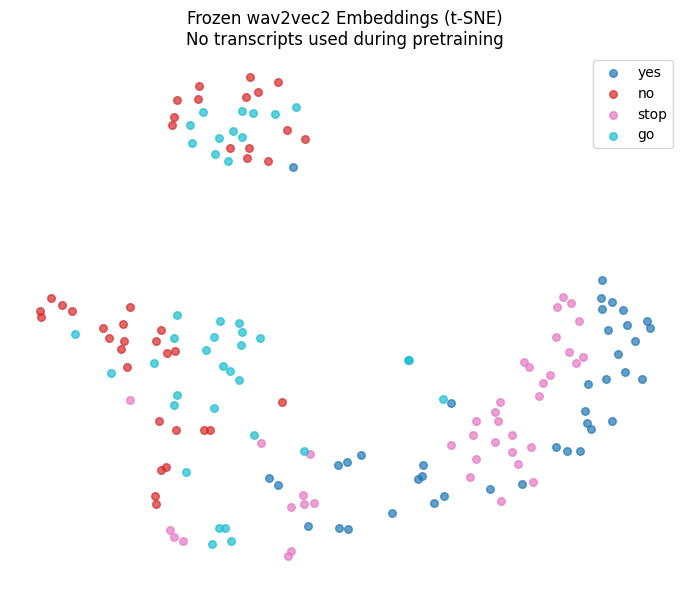

In [18]:
# ── Train a linear probe on the frozen features (same protocol as the SSL lab) ─
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

X_train, X_test, y_train, y_test = train_test_split(
    X.numpy(), y.numpy(), test_size=0.3, random_state=42, stratify=y.numpy())

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

linear_probe = nn.Linear(X.shape[1], len(PROBE_WORDS))
opt_probe = torch.optim.Adam(linear_probe.parameters(), lr=1e-2)

for epoch in range(100):
    logits = linear_probe(X_train_t)
    loss = F.cross_entropy(logits, y_train_t)
    opt_probe.zero_grad(); loss.backward(); opt_probe.step()

with torch.no_grad():
    test_acc = (linear_probe(X_test_t).argmax(1) == y_test_t).float().mean().item()
print(f'Linear probe test accuracy: {test_acc*100:.1f}%  (random baseline: {100/len(PROBE_WORDS):.1f}%)')

# t-SNE visualization, same style as the SSL lab's embedding plots
proj = TSNE(n_components=2, random_state=42, perplexity=15).fit_transform(X.numpy())
plt.figure(figsize=(7, 6))
colors_map = plt.cm.tab10(np.linspace(0, 1, len(PROBE_WORDS)))
for i, word in enumerate(PROBE_WORDS):
    mask = y.numpy() == i
    plt.scatter(proj[mask, 0], proj[mask, 1], c=[colors_map[i]], label=word, alpha=0.7, s=30)
plt.legend()
plt.title('Frozen wav2vec2 Embeddings (t-SNE)\nNo transcripts used during pretraining')
plt.axis('off')
plt.tight_layout(); plt.show()


---
# Part 5: Voice Cloning + Accent TTS — OpenVoice

## 5.1 What Is Voice Cloning?

So far, our TTS pipeline produces *some* voice — a fixed timbre baked into the model's decoder weights. Voice cloning asks a different question: **can the model speak in a specific person's voice, given only a short reference clip of that person talking?**

This is the same "encode → decode" idea from earlier parts, but now applied to **who is speaking** rather than **what is being said**:

```
Reference audio (your voice, 5-10 seconds)
      ↓  [Speaker Encoder]
Speaker embedding (a fixed-size vector that captures timbre, pitch range, accent)
      ↓
Text → [Base TTS model] → Mel Spectrogram, conditioned on the speaker embedding
      ↓  [Vocoder]
Audio waveform — text spoken in the cloned voice
```

The speaker embedding is conceptually the same kind of object as the `[EN-US]` accent tag from Part 1's tokenizer: a single vector injected into the model that conditions everything downstream. The difference is *what* it conditions — accent tags shape pronunciation and rhythm, a speaker embedding shapes timbre and identity.

## 5.2 OpenVoice — Disentangling "Who" from "How"

**OpenVoice** (Qin et al., MyShell AI, 2023) is built around one key design choice: it separates **tone color** (the static, identity-defining part of a voice — roughly: who it sounds like) from **style** (the dynamic part — accent, rhythm, pauses). This separation is exactly the same intuition we built in Part 1 and Part 2: identity and expression are different axes of the signal, and a good architecture should let you control them independently.

```
Reference voice clip (you, ~5-10s)
      ↓
Tone Color Extractor → tone color embedding (who you sound like)
                                    │
Base TTS output (any accent, any language) ──┤
      ↓  [Tone Color Converter]              │
Output audio in YOUR tone color, but keeping the base model's accent/prosody
```

Concretely, OpenVoice works in two stages:
1. A **base speaker TTS model** synthesizes speech in a reference accent (EN-US, EN-BR, EN-India, EN-AU).
2. A **tone color converter** takes that output and re-renders it in your cloned tone color, while *preserving* the rhythm and pacing of the base output.

This is why OpenVoice supports **cross-lingual cloning** (clone an English voice, speak Spanish) and **flexible accent control** — tone color and accent never get tangled together in the first place.

**Model:** `myshell-ai/OpenVoiceV2` on Hugging Face. **Paper:** Qin et al. (2023), *OpenVoice: Versatile Instant Voice Cloning*, https://arxiv.org/abs/2312.01479.


## 5.3 What This Looks Like in Practice

<img src="figures/voice_cloning_toolbox.png" title="Real-time voice cloning toolbox: speaker embedding UMAP projection (left) and generated mel spectrogram (right)" style="width: 700px;" />

The left panel shows speaker embeddings projected to 2D (UMAP) — each cluster of points is one speaker's reference clips, grouped by *who* they sound like, independent of *what* they said. This is the kind of representation a tone color extractor produces. The right panel is the synthesized mel spectrogram for new text in a cloned voice, generated the same way as the spectrograms in Part 2.

In [19]:
!git clone https://github.com/myshell-ai/OpenVoice.git

fatal: destination path 'OpenVoice' already exists and is not an empty directory.


In [20]:
# ── Install + load OpenVoice from Hugging Face ────────────────────────────
# !pip install -q melo-tts openvoice-cli huggingface_hub
import os, glob
from huggingface_hub import snapshot_download
from openvoice import se_extractor
from openvoice.api import ToneColorConverter

os.makedirs('data/voice_clone', exist_ok=True)

ckpt_dir = snapshot_download(repo_id='myshell-ai/OpenVoiceV2')
device = 'cuda' if torch.cuda.is_available() else 'cpu'

tone_color_converter = ToneColorConverter(f'{ckpt_dir}/converter/config.json', device=device)
tone_color_converter.load_ckpt(f'{ckpt_dir}/converter/checkpoint.pth')
print('OpenVoiceV2 loaded from Hugging Face.')

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



Fetching 17 files: 100%|██████████| 17/17 [00:00<00:00, 80386.89it/s]
/home/todsavadt/.local/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Loaded checkpoint '/home/todsavadt/.cache/huggingface/hub/models--myshell-ai--OpenVoiceV2/snapshots/f36e7edfe1684461a8343844af60babc2efbb727/converter/checkpoint.pth'
missing/unexpected keys: [] []
OpenVoiceV2 loaded from Hugging Face.


In [24]:
import os

for root, dirs, files in os.walk(ckpt_dir):
    level = root.replace(ckpt_dir, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        size = os.path.getsize(os.path.join(root, f))
        print(f'{indent}  {f}  ({size/1e6:.1f} MB)')

f36e7edfe1684461a8343844af60babc2efbb727/
  .gitattributes  (0.0 MB)
  .DS_Store  (0.0 MB)
  README.md  (0.0 MB)
  converter/
    config.json  (0.0 MB)
    checkpoint.pth  (131.3 MB)
  base_speakers/
    .DS_Store  (0.0 MB)
    ses/
      fr.pth  (0.0 MB)
      kr.pth  (0.0 MB)
      en-default.pth  (0.0 MB)
      en-br.pth  (0.0 MB)
      zh.pth  (0.0 MB)
      en-newest.pth  (0.0 MB)
      es.pth  (0.0 MB)
      jp.pth  (0.0 MB)
      en-india.pth  (0.0 MB)
      en-au.pth  (0.0 MB)
      en-us.pth  (0.0 MB)


In [25]:
import glob
ses = glob.glob(f'{ckpt_dir}/base_speakers/ses/*.pth')
for s in ses:
    print(os.path.basename(s))

fr.pth
kr.pth
en-default.pth
en-br.pth
zh.pth
en-newest.pth
es.pth
jp.pth
en-india.pth
en-au.pth
en-us.pth


In [21]:
# ── Extract a tone color embedding from a reference voice clip ────────────
# Put your own ~10-30s recording at data/voice_clone/my_voice.wav
reference_path = 'data/voice_clone/my_voice.mp3'

target_se, audio_name = se_extractor.get_se(
    reference_path, tone_color_converter, target_dir='data/voice_clone/processed', vad=True)

print(f'Extracted tone color embedding: shape {target_se.shape}')
print('This single vector now encodes "what you sound like" — independent of what you say.')

OpenVoice version: v2
[(0.0, 12.949375)]
after vad: dur = 12.948979591836734
Extracted tone color embedding: shape torch.Size([1, 256, 1])
This single vector now encodes "what you sound like" — independent of what you say.


/home/todsavadt/.local/lib/python3.10/site-packages/torch/functional.py:681: UserWarning: stft with return_complex=False is deprecated. In a future pytorch release, stft will return complex tensors for all inputs, and return_complex=False will raise an error.
Note: you can still call torch.view_as_real on the complex output to recover the old return format. (Triggered internally at /pytorch/aten/src/ATen/native/SpectralOps.cpp:874.)
  return _VF.stft(  # type: ignore[attr-defined]


In [ ]:
# !git clone https://github.com/myshell-ai/MeloTTS.git

In [ ]:
# !python3 -m unidic download

In [32]:
style_to_se = {
    'us':    ('en-us.pth',    'EN-US'),
    'br':    ('en-br.pth',    'EN-BR'),
    'india': ('en-india.pth', 'EN_INDIA'),
    'au':    ('en-au.pth',    'EN-AU'),
}

accents = ['us', 'br', 'india', 'au']
print('Available speaker IDs:', list(speaker_ids.keys()))

for accent in accents:
    base_path = f'data/voice_clone/base_{accent}.wav'
    out_path  = f'data/voice_clone/cloned_{accent}.wav'

    se_file, spk_key = style_to_se[accent]
    spk_id = speaker_ids.get(spk_key, speaker_ids.get('EN-US'))

    base_speaker_tts.tts_to_file(text, spk_id, base_path, speed=1.0)

    source_se = torch.load(f'{ckpt_dir}/base_speakers/ses/{se_file}', map_location=device)
    tone_color_converter.convert(
        audio_src_path=base_path,
        src_se=source_se,
        tgt_se=target_se,
        output_path=out_path,
        tau=0.3
    )
    print(f'[{accent:8}] se={se_file}, spk={spk_key} → {out_path}')
    display(Audio(out_path))


 > Text split to sentences.
This is what my cloned voice sounds like, speaking with a different style.
 > ===========================


100%|██████████| 1/1 [00:00<00:00, 15.51it/s]

[english    ] se=en-default.pth → data/voice_clone/cloned_english.wav


 > Text split to sentences.
This is what my cloned voice sounds like, speaking with a different style.
 > ===========================


100%|██████████| 1/1 [00:00<00:00, 26.09it/s]


...

100%|██████████| 1/1 [00:00<00:00, 26.17it/s]


[newest     ] se=en-newest.pth → data/voice_clone/cloned_newest.wav


 > Text split to sentences.
This is what my cloned voice sounds like, speaking with a different style.
 > ===========================


100%|██████████| 1/1 [00:00<00:00, 25.00it/s]


[us         ] se=en-us.pth → data/voice_clone/cloned_us.wav


## 5.4 Did the Clone Keep the Style? Mel Spectrogram Comparison

The whole point of separating tone color from style is that converting to your voice should **not** flatten out the style differences from Stage 1. Let's check this directly by comparing the mel spectrograms of the four styles, all rendered in the same cloned voice.

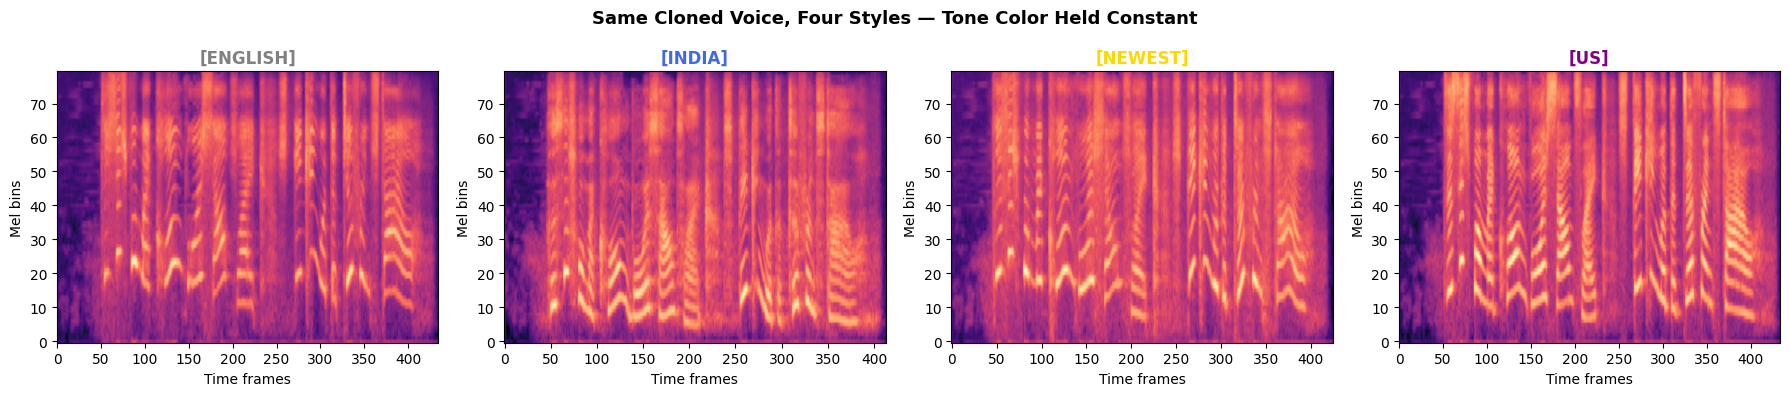

In [34]:
# ── Mel spectrogram grid: same cloned voice, four different styles ────────
import torchaudio
import torchaudio.transforms as T

STYLE_COLORS = {'english': 'gray', 'india': 'royalblue', 'newest': 'gold', 'us': 'purple'}
mel_tf = T.MelSpectrogram(sample_rate=22050, n_fft=1024, hop_length=256, n_mels=80)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, style in zip(axes, styles):
    wvf, sr = torchaudio.load(f'data/voice_clone/cloned_{style}.wav')
    if sr != 22050:
        wvf = T.Resample(sr, 22050)(wvf)
    mel = mel_tf(wvf[0].unsqueeze(0)).squeeze()
    log_mel = torch.log(mel + 1e-9)
    ax.imshow(log_mel.numpy(), aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'[{style.upper()}]', color=STYLE_COLORS[style], fontweight='bold')
    ax.set_xlabel('Time frames'); ax.set_ylabel('Mel bins')
    
plt.suptitle('Same Cloned Voice, Four Styles — Tone Color Held Constant', fontsize=13, fontweight='bold')
plt.tight_layout(); 
plt.show()

## 5.5 Cross-Lingual Cloning

Because tone color is disentangled from style — and style is what carries language-specific prosody — OpenVoice can take a tone color extracted from an **English** reference clip and apply it to a **base speaker model in a different language**. The cloned voice keeps your timbre while speaking a language you may never have spoken in the reference clip.

```
Your English reference clip → tone color embedding (language-independent identity)
                                          │
Spanish base speaker TTS output ─────────┤
        ↓  [Tone Color Converter]
Output: Spanish speech, in your voice
```

This only works *because* the tone color extractor was never trained to care about phonemes or language — it only models the acoustic properties of the *voice itself* (formant structure, pitch range, vocal tract characteristics). Compare this to the character/phoneme tokenizers from Part 1: those are language-specific by construction (a phoneme set is defined per language), while a tone color embedding is not.

| | Emotion tags (Part 1 tokenizer) | OpenVoice tone color |
|---|---|---|
| What it conditions | Prosody (pitch, rate, energy) | Timbre, identity |
| How it's represented | A single discrete token | A continuous embedding vector |
| Where it comes from | A fixed vocabulary you define | Extracted from a reference clip |
| Reusable across languages? | No — tied to the text tokenizer | Yes — purely acoustic |

In [ ]:
# ── Cross-lingual cloning: same tone color, different base-speaker language ─
cross_lingual_texts = {
    'EN': "Hello, this is a test of cross lingual voice cloning.",
    'ES': "Hola, esta es una prueba de clonacion de voz entre idiomas.",
    'FR': "Bonjour, ceci est un test de clonage vocal interlingue.",
}

for lang, text_lang in cross_lingual_texts.items():
    base_tts = MeloTTS(language=lang, device=device)
    spk_ids  = base_tts.hps.data.spk2id
    spk_key  = list(spk_ids.keys())[0]

    base_path = f'data/voice_clone/base_{lang}.wav'
    out_path  = f'data/voice_clone/cloned_{lang}.wav'

    base_tts.tts_to_file(text_lang, spk_ids[spk_key], base_path, speed=1.0)
    source_se = torch.load(f'{ckpt_dir}/base_speakers/ses/{lang.lower()}.pth', map_location=device)
    tone_color_converter.convert(
        audio_src_path=base_path, src_se=source_se, tgt_se=target_se, output_path=out_path)

    print(f'[{lang}] "{text_lang}"')
    display(Audio(out_path))

# Exercises

## Exercise 1: Speech vs NLP Tokenization — Building Intuition

a) Using the `SpeechTokenizer` defined in Part 1, tokenize the following sentences and fill in the table:

```python
sentences = [
    "Hello, how are you?",
    "Dr. Smith prescribed 10 tablets.",
    "[EN-US] I got the job!",
    "[EN-BR] I lost my wallet.",
    "[EN-INDIA] This is completely unacceptable!",
]
```

| Sentence | # Char tokens | # Tokens (with BOS/EOS) | Accent tag token ID |
|---|---|---|---|
| Hello, how are you? | ? | ? | — |
| Dr. Smith prescribed 10 tablets. | ? | ? | — |
| [EN-US] I got the job! | ? | ? | ? |
| [EN-BR] I lost my wallet. | ? | ? | ? |
| [EN-INDIA] This is completely unacceptable! | ? | ? | ? |

b) In the tokenizer's `normalize()` method, `"Dr. Smith"` becomes `"doctor smith"`. Why is this normalization critical for TTS? What would happen if the model received `"Dr."` as input?

c) In NLP, `[CLS]` is a special token that summarizes the sequence. In speech, the accent tag `[EN-US]` is also a single special token at the beginning. Explain the **architectural similarity** — how does a single token influence the model's entire output?

---

## Exercise 2: CTC — Verifying the Forward Algorithm

a) Pick 3 short hand-built alignments (lists of characters, like the `examples` list in Part 3.2) that should all collapse to the same word. Run them through `ctc_collapse` and confirm they agree.

b) Using `ctc_forward_log_prob` from Part 3.4, compute $P_{CTC}(Y \mid X)$ for the same random `log_probs` matrix but for two *different* target words of the same length (e.g. `"HEL"` vs `"LEH"`). They should generally get different probabilities — explain in 1-2 sentences why this is expected given the model's output at each frame.

c) Modify the toy training loop in Part 3.5 to track **character error rate** (edit distance between decoded and true word, divided by word length) instead of just loss. Plot character error rate vs. training step. At what step does it drop below 10%?

d) Re-run the greedy decoding visualization (Part 3.5's last cell) with `frames_per_char=(1, 2)` instead of `(3, 8)` in `synthesize_frames`. Does accuracy get better or worse with much shorter character durations? Explain why, referencing how many frames the model has to "agree" on a character before collapsing.

---

## Exercise 3: wav2vec2 — How Much Does Self-Supervision Actually Buy You?

a) Repeat the Part 4.3 linear probe, but using **raw mel-spectrogram features** (mean-pooled over time, like in Part 2) instead of wav2vec2 embeddings, as your baseline. Fill in:

| Feature | Test Accuracy |
|---|---|
| Raw mel-spectrogram (mean-pooled) | ? |
| wav2vec2 (frozen, mean-pooled) | ? |

b) By how much does wav2vec2 improve over the raw-feature baseline? Compare this gap to the gap you measured between an MLP-on-raw-pixels baseline and a pretrained SSL encoder (SimCLR/DINO/MAE) in the SSL lab — is the speech gap bigger, smaller, or about the same order of magnitude?

c) Increase `PROBE_WORDS` to include at least 6 SpeechCommands classes instead of 4. Does linear-probe accuracy drop, and if so, is the drop proportional to the increase in classes (i.e., does it stay well above the new random baseline)?

d) wav2vec2 was pretrained with a **contrastive** loss against quantized targets, while MAE (SSL lab) used **reconstruction**. Based on what you've now measured in both labs, which inductive bias seems to transfer better to a completely different downstream task — and is the comparison even fair given the very different data modalities?

---

## Exercise 4: Voice Cloning — Identity, Style, and Language

a) Using your own ~10-30s recording, extract a tone color embedding and synthesize the test sentence from Part 5 in all four accents (`us`, `br`, `india`, `au`). For each, record:

| Accent | Duration (s) | RMS Energy | Mel Spectral Centroid |
|---|---|---|---|
| us | ? | ? | ? |
| br | ? | ? | ? |
| india | ? | ? | ? |
| au | ? | ? | ? |

b) Listen to all four clips. Does it still sound like *you* in every style, or does the cloned voice drift toward a different-sounding speaker in some accents? Compute the cosine similarity between the tone color embedding extracted from your **reference clip** and a tone color embedding extracted from each of the **four generated clips** (re-run `se_extractor.get_se` on the outputs). If OpenVoice's disentanglement is working well, what should these similarities look like — high and roughly equal across all four accents, or otherwise?

---

## Submission

Submit your work to GitHub. Your repository should contain:

### 1. Training Script (`run.py`)

```bash
# Train the toy CTC model (Part 3 / Exercise 2)
python3 run.py --model ctc --epochs 300 --train

# Linear-probe a pretrained wav2vec2 checkpoint (Part 4 / Exercise 3)
python3 run.py --model wav2vec2-probe --dataset speechcommands --classes yes,no,stop,go --train

# Extract tone color from your reference clip
python3 run.py --model voice-clone --extract-se --reference my_voice.wav

# Synthesize in a given style with your cloned voice
python3 run.py --model voice-clone --accent us --text "I got the job!" --generate

# Synthesize all styles for comparison
python3 run.py --model voice-clone --accent all --text "Hello world" --generate

# Cross-lingual cloning
python3 run.py --model voice-clone --language es --text "Hola, como estas?" --generate
```

### 2. `README.md`

Your `README.md` must include:

**Commands used** (exact commands you ran)

**Results table:**

| Task | Model / Method | Result | Notes |
|---|---|---|---|
| Tokenization (Ex 1) | SpeechTokenizer | — | char vs word count table |
| CTC character error rate (Ex 2) | Toy BiLSTM + CTC | ? % CER | error rate vs training step |
| wav2vec2 vs raw-feature probe (Ex 3) | Linear probe | ? % vs ? % | wav2vec2 vs mel-spectrogram baseline |
| Voice cloning: accent + cross-lingual (Ex 4) | OpenVoice | ? cosine sim / ? quality | identity-vs-accent and language transfer |

**Visualizations** (include in README or as separate image files):
- CTC greedy decoding grid + character error rate curve (Part 3 / Exercise 2)
- wav2vec2 vs mel-spectrogram linear probe comparison + t-SNE plot (Part 4 / Exercise 3)
- Mel spectrogram grid: same cloned voice across 4 accents (Part 5.4)
- Tokenization comparison: NLP tokens vs speech chars vs accent tokens (Part 1)

**Discussion** (3–5 sentences): How does understanding speech tokenization and CTC alignment change how you think about training a TTS or ASR model? Why is a tone color embedding fundamentally a different kind of object than a text token or a CTC blank, even though all three "condition" or shape a model's output?